# 1. Definição do Problema de Negócio

Uma empresa de e-commerce deseja automatizar a análise de feedback de seus clientes. Atualmente, a análise é feita manualmente, o que é um processo lento, caro e que não escala com o volume de reviews recebidos diariamente. (A empresa é fictícia, os dados tirados a partir do csv também são fictícios e apenas para fim de execução do projeto).

**Objetivo:**
Criar um modelo de Machine Learning que classifique automaticamente os reviews de produtos como 'positivo' ou 'negativo'.

**Benefícios Esperados:**
* Eficiência: Reduzir o tempo e o custo da análise de feedback.
* Tomada de Decisão Rápida: Permitir que as equipes de produto e marketing identifiquem rapidamente produtos com problemas ou oportunidades de melhoria.
* Priorização: Direcionar reviews negativos para a equipe de suporte ao cliente de forma prioritária, melhorando a experiência do consumidor.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import string
from collections import Counter
from nltk.corpus import stopwords
from src.config import settings

In [2]:
df = pd.read_csv(settings.data_path)

df.shape

(500, 3)

In [3]:
df.info()

print("\nVerificando valores ausentes:\n")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   review_id     500 non-null    int64 
 1   texto_review  488 non-null    object
 2   sentimento    500 non-null    object
dtypes: int64(1), object(2)
memory usage: 11.8+ KB

Verificando valores ausentes:

review_id        0
texto_review    12
sentimento       0
dtype: int64



Distribuição dos Sentimentos:



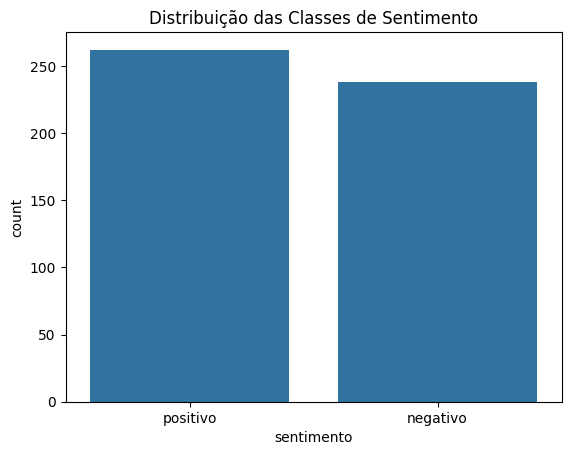

In [4]:
print("\nDistribuição dos Sentimentos:\n")
sns.countplot(x = 'sentimento', data = df)
plt.title('Distribuição das Classes de Sentimento')
plt.show()

In [10]:
pd.set_option('display.max_colwidth', None)

print("Exemplos de Reviews Positivos:")
display(df[df['sentimento'] == 'positivo'].head(5))

print("\nExemplos de Reviews Negativos:")
display(df[df['sentimento'] == 'negativo'].head(5))

Exemplos de Reviews Positivos:


,review_id,texto_review,sentimento,contagem_palavras
0,1,Estou muito feliz com a compra. O cadeira gamer é incrível e chegou no prazo.,positivo,15
4,5,É UM LIVRO OK PELO PRÇEO QUE PAGUEI.,positivo,8
7,8,Recebi o fone de ouvido hoje. Vou começar a usar para ver se é bom.,positivo,15
9,10,Ótimo custo-benefício. O celular é excelente e muito útil.,positivo,9
10,11,Ótimo custo-benefício. O livro é fantástica e muito útil.,positivo,9



Exemplos de Reviews Negativos:


,review_id,texto_review,sentimento,contagem_palavras
1,2,NaN,negativo,1
2,3,Não recomendo. A entrega foi lenta e o celular não é como na foto.,negativo,14
3,4,O monitor é decepcionante. O suporte ao cliente foi horrível.,negativo,10
5,6,Não rceomendo. A entrega atrasou muito e o monitor não é como na foto.,negativo,14
6,7,Péssima experiência. O livro quebrou no primeiro dia de uso. Decepcionado.,negativo,11


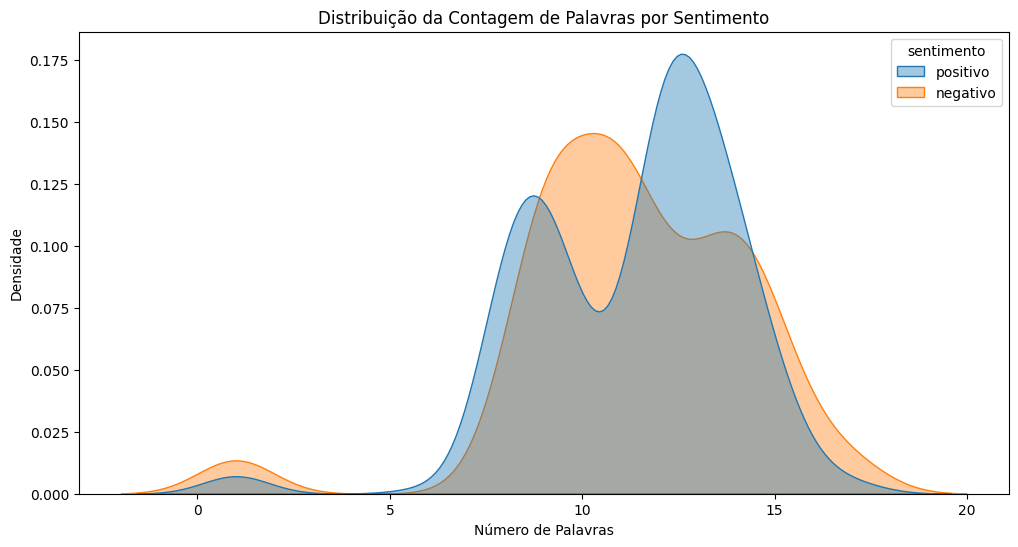

In [6]:
df['contagem_palavras'] = df['texto_review'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12,6))

sns.kdeplot(
    data=df,
    x='contagem_palavras',
    hue='sentimento',
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.title('Distribuição da Contagem de Palavras por Sentimento')
plt.xlabel('Número de Palavras')
plt.ylabel('Densidade')

plt.show()

[nltk_data] Downloading package stopwords to /home/pedroa-
[nltk_data]     bg/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


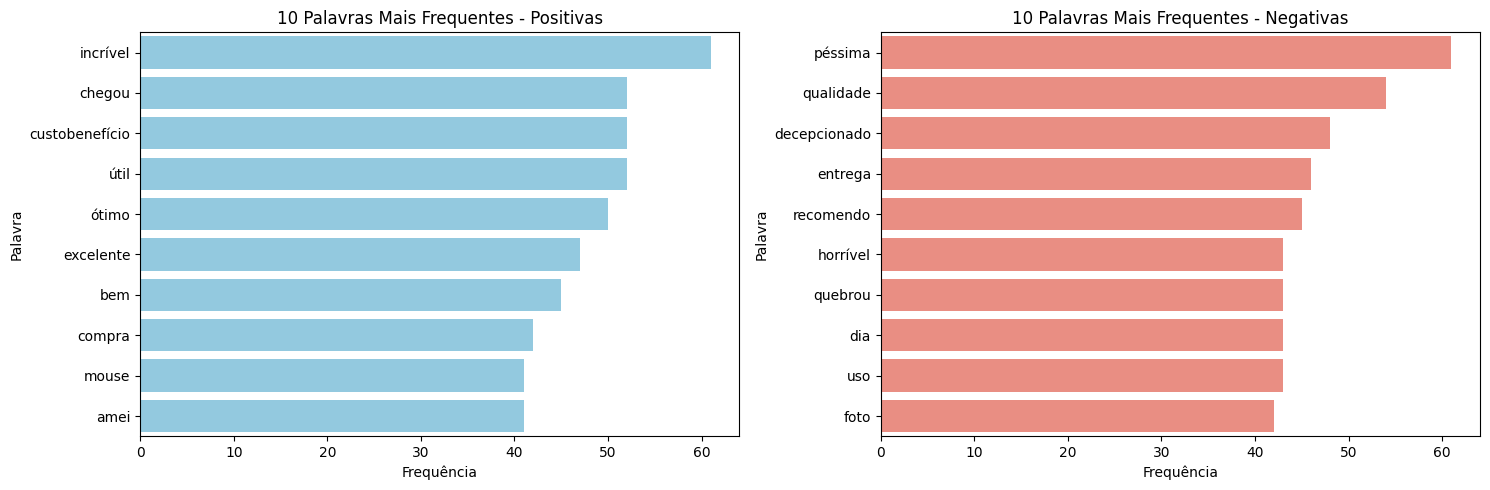

In [7]:
nltk.download('stopwords')
stop_words = set(stopwords.words('portuguese'))

def contar_palavras(textos):
    palavras = []
    
    for texto in textos.dropna():
        texto = texto.lower()
        texto = texto.translate(str.maketrans('', '', string.punctuation))
        
        for palavra in texto.split():
            if palavra not in stop_words:
                palavras.append(palavra)
                
    return Counter(palavras)

freq_positivo = contar_palavras(df[df["sentimento"] == "positivo"]["texto_review"])
freq_negativo = contar_palavras(df[df["sentimento"] == "negativo"]["texto_review"])

top_pos = freq_positivo.most_common(10)
top_neg = freq_negativo.most_common(10)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de Palavras Positivas
sns.barplot(
    x=[x[1] for x in top_pos],
    y=[x[0] for x in top_pos],
    ax=ax[0],
    color='skyblue'
)
ax[0].set_title("10 Palavras Mais Frequentes - Positivas")
ax[0].set_xlabel("Frequência")
ax[0].set_ylabel("Palavra")

# Gráfico de Palavras Negativas
sns.barplot(
    x=[x[1] for x in top_neg],
    y=[x[0] for x in top_neg],
    ax=ax[1],
    color='salmon'
)
ax[1].set_title("10 Palavras Mais Frequentes - Negativas")
ax[1].set_xlabel("Frequência")
ax[1].set_ylabel("Palavra")

plt.tight_layout()
plt.show()

### Conclusões da Análise Exploratória

1. **Qualidade dos Dados:** Foram identificados 12 valores nulos que deverão ser tratados na etapa de pré-processamento.

2. **Balanceamento das Classes:** As classes de sentimentos (positivos e negativos) apresentam distribuição equilibrada, não indicando problemas de desbalanceamento para o treinamento dos modelos.

3. **Padrão de Escrita:** A distribuição da contagem de palavras mostra grande sobreposição entre avaliações positivas e negativas. Observa-se uma leve tendência de avaliações positivas serem um pouco mais longas, porém o comprimento do texto, isoladamente, não parece ser suficiente para distinguir o sentimento das avaliações.

4. **Vocabulário dos Reviews:** As palavras mais frequentes refletem claramente o sentimento das avaliações. Reviews positivos são marcados por termos como *"incrível"*, *"excelente"* e *"ótimo"*, enquanto reviews negativos apresentam palavras como *"péssima"*, *"horrível"*, *"decepcionado"* e *"quebrou"*. Além disso, termos como *"entrega"* e *"compra"* que aparecem nas classes, indicam palavras comuns usadas no âmbito da análise em questão, não podenso ser usadas como indicadores de forma precisa.

